# Experimenting with ML Model Parameters

## 📚 Learning Objectives

By completing this notebook, you will:
- Experiment with changes in ML model parameters
- Observe changes in model fit to training data
- Understand the impact of parameter changes on model behavior
- Connect linear algebra concepts to ML model optimization

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 3, lesson 04 "Gradient Descent and Loss Functions" — you already swept the learning rate by hand there; here the same parameter changes are read through a linear-algebra lens.

**Used later in:** Course 04 (AIAT 114) — Unit 5, lesson 01 "Grid Search and Random Search" — which automates the sweep you are doing manually.

---

This notebook covers practical activities from **Course 03, Unit 1**:
- Experimenting with changes in ML model parameters and observing changes in model fit

---

## Introduction

**Model parameters** can be viewed as vectors in parameter space. Changes to these parameters directly affect how well the model fits the training data. Understanding this relationship is fundamental to machine learning optimization.


---

## 📌 Real case: 442 patients, ten measurements, R² = 0.45

The dataset in this notebook is not a teaching prop. It is the cohort from Efron, Hastie, Johnstone and
Tibshirani's 2004 *Annals of Statistics* paper **"Least Angle Regression"** — 442 real diabetes patients,
ten baseline measurements each (age, sex, BMI, average blood pressure, six blood-serum readings), with the
target being how far the disease had progressed one year later. scikit-learn ships it because that paper
made it the standard test bed for regression with correlated predictors.

Now read what the baseline cell prints: **R² = 0.4526** on held-out patients. The best straight-line model
of ten clinical measurements explains under half the variation in how a real patient's diabetes progresses
— and that result was worth publishing in a leading statistics journal. This is what real medical data
looks like. A tutorial that shows you R² = 0.98 has shown you a simulation.

**What goes wrong without this.** Treat a fitted parameter vector as a row of independent knobs and you
will "improve" the model by turning one, never noticing that the fit was a joint compromise across all ten.
The experiment below makes the point brutally: *every* edit to the fitted vector — halving it, stretching
it, jittering it — sends test R² negative, i.e. worse than predicting the mean for every patient.
"Optimized" means the vector sits at a point where no small move in any direction helps.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: NumPy/Matplotlib plus sklearn's linear models (LinearRegression, Ridge, Lasso),
# the real diabetes dataset, a scaler, and metrics - the tools for the parameter experiments below.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Confirm the environment is ready before any math starts.
print("✅ Libraries imported!")
print("\nExperimenting with ML Model Parameters")
print("=" * 60)


✅ Libraries imported!

Experimenting with ML Model Parameters


---

## 🌉 Bridge: The ML Model We Use as a Black Box

This notebook experiments with a scikit-learn **LinearRegression** model — machinery that is taught properly later (loss functions and regularization in Unit 3, notebooks 02-04; how models learn in Course 04). Here we use the model **as a black box** whose learned parameters form a *vector* — the linear-algebra object this unit is about. The minimum you need to follow along:

- **Linear model**: predictions are ŷ = Xw + b — a matrix-vector product (Unit 1 material!). *Fitting* means finding the weight vector w and intercept b that make ŷ close to y.
- **MSE** (mean squared error): the average of (y − ŷ)². Lower is better; 0 is perfect.
- **R²**: the fraction of the target's variance the model explains — 1.0 is perfect, 0 means no better than always predicting the mean.
- **Train/test split**: fit on one part of the data, evaluate on a held-out part, so the score measures generalization rather than memorization.
- **Ridge alpha (Part 2)**: a penalty on large weights; bigger α shrinks the weight vector's norm ‖θ‖. Slogan level here — Unit 3, notebook 02 explains why.

**The point of this notebook**: parameters are just vectors, so we can scale them, add noise to them, and measure their norm. Everything else is previewed here and taught fully later — **Course 04 opens the black box**.

## Part 1: Linear Regression Parameter Experiments


In [2]:
# Baseline experiment: fit plain linear regression on a REAL medical dataset.
# There is no "true" weight vector to recover here - the coefficients are whatever the
# real patients' data implies, which is exactly the situation you meet in practice.

print("=" * 60)
print("Part 1: Linear Regression Parameter Experiments")
print("=" * 60)

# Real dataset: sklearn's diabetes study - 442 patients, 10 baseline measurements
# (age, sex, BMI, average blood pressure and six blood-serum readings). The target is
# a quantitative measure of disease progression one year after baseline.
diabetes = load_diabetes()
X_all, y = diabetes.data, diabetes.target
param_names = list(diabetes.feature_names)

print(f"\nDataset: diabetes progression - {X_all.shape[0]} patients, {X_all.shape[1]} features")
print(f"Features: {param_names}")
print(f"Target range: {y.min():.0f} to {y.max():.0f} (disease progression score)")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

# Standardize the features so every coefficient is measured on the same footing.
# This matters for Part 2: a regularization penalty on ||theta|| is only fair if the
# features share a scale.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# Train baseline model
model_baseline = LinearRegression()
model_baseline.fit(X_train, y_train)

print("\nBaseline Model Parameters (weights) - one per feature:")
for name, w in zip(param_names, model_baseline.coef_):
    print(f"  {name:>4}: {w:8.3f}")
print(f"Intercept: {model_baseline.intercept_:.4f}")
print(f"Parameter vector norm ||theta||: {np.linalg.norm(model_baseline.coef_):.4f}")

# Evaluate
y_pred_baseline = model_baseline.predict(X_test)
mse_baseline = mean_squared_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)

print("\nBaseline Performance:")
print(f"MSE: {mse_baseline:.4f}")
print(f"R²: {r2_baseline:.4f}")


Part 1: Linear Regression Parameter Experiments

Dataset: diabetes progression - 442 patients, 10 features
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target range: 25 to 346 (disease progression score)

Training samples: 353
Test samples: 89

Baseline Model Parameters (weights) - one per feature:
   age:    1.754
   sex:  -11.512
   bmi:   25.607
    bp:   16.829
    s1:  -44.449
    s2:   24.641
    s3:    7.677
    s4:   13.139
    s5:   35.161
    s6:    2.351
Intercept: 153.7365
Parameter vector norm ||theta||: 71.6297

Baseline Performance:
MSE: 2900.1936
R²: 0.4526


In [3]:
# Experiment: Modify parameters manually.
# The parameter vector is just a vector, so we can halve it, stretch it, or jitter it and
# measure what each edit costs. The random jitter here is deliberate noise INJECTED into a
# real fitted model - the randomness is the experiment, not the data.

print("\n" + "=" * 60)
print("Experiment: Modifying Parameters Manually")
print("=" * 60)

baseline_params = np.concatenate([model_baseline.coef_, [model_baseline.intercept_]])

# Create modified models with different parameter vectors
rng = np.random.default_rng(42)  # seeded so the jitter is reproducible
params_scaled_05 = baseline_params * 0.5
params_scaled_15 = baseline_params * 1.5
# Jitter scaled to the size of the weights themselves (real coefficients here are ~1-60)
params_noise = baseline_params + 0.1 * np.linalg.norm(baseline_params) * rng.normal(size=len(baseline_params))


def evaluate_params(X, y, params):
    """Evaluate model with given parameters"""
    coef = params[:-1]
    intercept = params[-1]
    y_pred = X @ coef + intercept
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    return mse, r2


print("\nParameter Modifications (evaluated on the held-out test patients):")
for name, params in [("Baseline", baseline_params),
                      ("Scaled 0.5x", params_scaled_05),
                      ("Scaled 1.5x", params_scaled_15),
                      ("With noise", params_noise)]:
    mse, r2 = evaluate_params(X_test, y_test, params)
    print(f"\n{name}:")
    print(f"  ||theta|| = {np.linalg.norm(params[:-1]):.3f}, intercept = {params[-1]:.2f}")
    print(f"  MSE: {mse:.4f}, R²: {r2:.4f}")

print("\nRead the table: every edit to the fitted vector makes the model worse on real")
print("patients. That is what 'the model was optimized' actually means.")



Experiment: Modifying Parameters Manually

Parameter Modifications (evaluated on the held-out test patients):

Baseline:
  ||theta|| = 71.630, intercept = 153.74
  MSE: 2900.1936, R²: 0.4526

Scaled 0.5x:
  ||theta|| = 35.815, intercept = 76.87
  MSE: 8963.0613, R²: -0.6917

Scaled 1.5x:
  ||theta|| = 107.445, intercept = 230.60
  MSE: 8359.9812, R²: -0.5779

With noise:
  ||theta|| = 104.792, intercept = 168.65
  MSE: 7505.4484, R²: -0.4166

Read the table: every edit to the fitted vector makes the model worse on real
patients. That is what 'the model was optimized' actually means.


## Part 2: Regularization Parameter Experiments



Part 2: Regularization Parameter Experiments

Regularization Effects on Parameters:
  Alpha  0.001: MSE=2900.1817, R²=0.4526, ||θ||=71.6150
  Alpha  0.010: MSE=2900.0751, R²=0.4526, ||θ||=71.4836
  Alpha  0.100: MSE=2899.0546, R²=0.4528, ||θ||=70.2143
  Alpha  1.000: MSE=2892.0146, R²=0.4541, ||θ||=60.9088
  Alpha 10.000: MSE=2875.7787, R²=0.4572, ||θ||=43.0280
  Alpha 100.000: MSE=2858.2243, R²=0.4605, ||θ||=34.2828


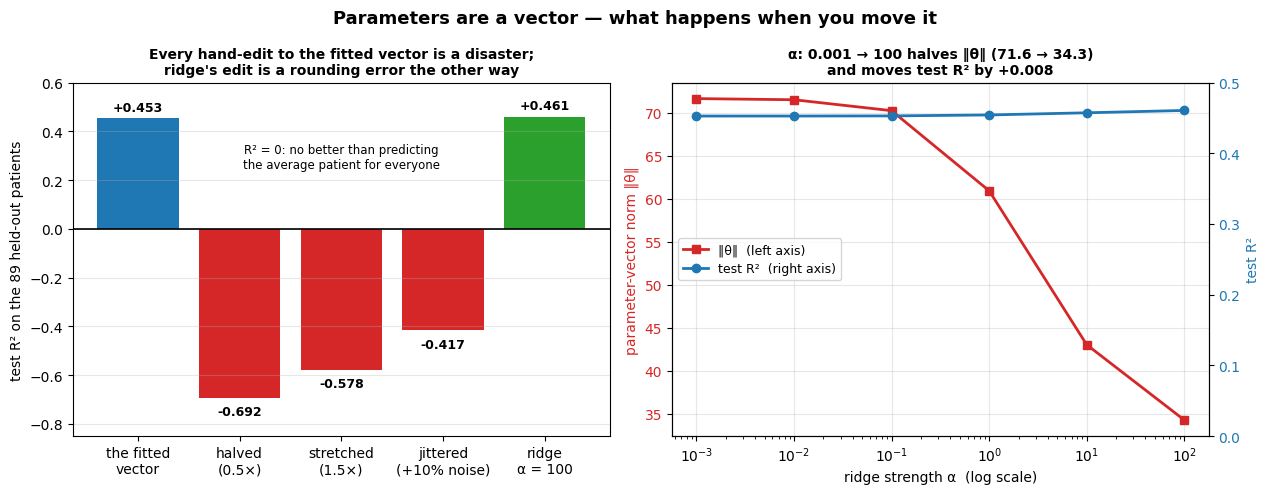


Reading the figure:
   fitted vector      R² = +0.4526
   halved (0.5×)      R² = -0.6917   <- worse than predicting the mean
   stretched (1.5×)   R² = -0.5779   <- worse than predicting the mean
   jittered (+10% noise) R² = -0.4166   <- worse than predicting the mean
   ridge, alpha = 100 R² = +0.4605   <- better than the fit, by +0.0079
   Over the whole sweep the norm falls 71.6 -> 34.3 while R² moves +0.0079.
   The right panel's R² axis runs 0 to 0.5 on purpose: on any honest scale that line is flat.

✅ Regularization parameter effects visualized!


In [4]:
# Sweep the Ridge regularization strength alpha across five orders of magnitude.
# Watch the trade-off: larger alpha shrinks the parameter norm ||θ|| while test error shifts.

print("\n" + "=" * 60)
print("Part 2: Regularization Parameter Experiments")
print("=" * 60)

# Experiment with different regularization strengths
alpha_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

# Train one Ridge model per alpha and record error and coefficient size.
ridge_results = []
for alpha in alpha_values:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    ridge_pred = ridge.predict(X_test)
    mse = mean_squared_error(y_test, ridge_pred)
    r2 = r2_score(y_test, ridge_pred)
    param_norm = np.linalg.norm(ridge.coef_)
    ridge_results.append({'alpha': alpha, 'mse': mse, 'r2': r2, 'param_norm': param_norm})

print("\nRegularization Effects on Parameters:")
for r in ridge_results:
    print(f"  Alpha {r['alpha']:6.3f}: MSE={r['mse']:.4f}, R²={r['r2']:.4f}, ||θ||={r['param_norm']:.4f}")

# VISUAL: both experiments of this notebook on one page, at a scale that does not flatter either.
# WHY the left panel: the sweep's numbers (MSE 2900 -> 2858) look dramatic if you zoom the axis onto
#      them. Put them next to what happens when you edit the vector by hand and the true size of the
#      ridge effect becomes obvious. An axis that starts at 2858 would have told you a different story.
# WHY the twin axes on the right: the trade-off IS between two different quantities - how big the
#      parameter vector is, and how well it predicts - so both belong on one x-axis, in matched colours.

r2_edits = {
    "the fitted\nvector": evaluate_params(X_test, y_test, baseline_params)[1],
    "halved\n(0.5\u00d7)": evaluate_params(X_test, y_test, params_scaled_05)[1],
    "stretched\n(1.5\u00d7)": evaluate_params(X_test, y_test, params_scaled_15)[1],
    "jittered\n(+10% noise)": evaluate_params(X_test, y_test, params_noise)[1],
    "ridge\n\u03b1 = 100": ridge_results[-1]["r2"],
}
alphas = [r["alpha"] for r in ridge_results]
r2s = [r["r2"] for r in ridge_results]
norms = [r["param_norm"] for r in ridge_results]

fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.0))

ax = axes[0]
colours = ["tab:blue", "tab:red", "tab:red", "tab:red", "tab:green"]
bars = ax.bar(list(r2_edits), list(r2_edits.values()), color=colours)
ax.axhline(0, color="black", lw=1.2)
ax.text(2.0, 0.25, "R\u00b2 = 0: no better than predicting\nthe average patient for everyone",
        fontsize=8.5, ha="center")
for bar, v in zip(bars, r2_edits.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, v + (0.03 if v > 0 else -0.07),
            f"{v:+.3f}", ha="center", fontsize=9, fontweight="bold")
ax.set_ylabel("test R\u00b2 on the 89 held-out patients")
ax.set_ylim(-0.85, 0.6); ax.grid(alpha=0.3, axis="y")
ax.set_title("Every hand-edit to the fitted vector is a disaster;\nridge's edit is a rounding error the other way",
             fontsize=10, fontweight="bold")

ax = axes[1]
ax.semilogx(alphas, norms, "s-", color="tab:red", lw=2, label="\u2016\u03b8\u2016  (left axis)")
ax.set_xlabel("ridge strength \u03b1  (log scale)")
ax.set_ylabel("parameter-vector norm \u2016\u03b8\u2016", color="tab:red")
ax.tick_params(axis="y", labelcolor="tab:red"); ax.grid(alpha=0.3)
ax2 = ax.twinx()
ax2.semilogx(alphas, r2s, "o-", color="tab:blue", lw=2, label="test R\u00b2  (right axis)")
ax2.set_ylabel("test R\u00b2", color="tab:blue"); ax2.tick_params(axis="y", labelcolor="tab:blue")
ax2.set_ylim(0.0, 0.5)                       # a scale on which "no better than the mean" is visible
ax.set_title(f"\u03b1: 0.001 \u2192 100 halves \u2016\u03b8\u2016 ({norms[0]:.1f} \u2192 {norms[-1]:.1f})\n"
             f"and moves test R\u00b2 by {r2s[-1] - r2s[0]:+.3f}", fontsize=10, fontweight="bold")
handles = ax.get_lines() + ax2.get_lines()
ax.legend(handles, [h.get_label() for h in handles], fontsize=9, loc="center left")

fig.suptitle("Parameters are a vector \u2014 what happens when you move it",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nReading the figure:")
print("=" * 66)
print(f"   fitted vector      R\u00b2 = {r2_edits['the fitted\nvector']:+.4f}")
for label in ["halved\n(0.5\u00d7)", "stretched\n(1.5\u00d7)", "jittered\n(+10% noise)"]:
    print(f"   {label.replace(chr(10), ' '):18s} R\u00b2 = {r2_edits[label]:+.4f}   <- worse than predicting the mean")
print(f"   ridge, alpha = 100 R\u00b2 = {r2_edits['ridge\n\u03b1 = 100']:+.4f}   <- better than the fit, by {r2s[-1] - r2_baseline:+.4f}")
print(f"   Over the whole sweep the norm falls {norms[0]:.1f} -> {norms[-1]:.1f} while R\u00b2 moves {r2s[-1] - r2s[0]:+.4f}.")
print("   The right panel's R\u00b2 axis runs 0 to 0.5 on purpose: on any honest scale that line is flat.")

print("\n✅ Regularization parameter effects visualized!")

**What to look for in the figure above.** The left panel puts every parameter vector this notebook tried
on one axis, scored on the same 89 held-out patients. The blue bar is the fitted vector (+0.453). The
three red bars are hand-edits of it — halved, stretched by half, jittered by 10% — and every one of them
falls **below the black line at R² = 0**, which marks the score you would get by ignoring the patient
entirely and predicting the average for everyone. That is what "the model was optimized" means in
practice: the vector is at a point where moving it in any of these directions does not degrade the model
gently, it destroys it.

The green bar is ridge at α = 100, and it is the honest half of the story: +0.461 against the fit's
+0.453. You have to read the printed digits to see any difference at all — the bars look the same height,
because they are.

The right panel is the same sweep in detail, and its two axes are coloured to match their curves. The red
squares show ‖θ‖ falling from 71.6 to 34.3: ridge really did halve the parameter vector. The blue circles
show test R² over that same sweep, drawn on a scale that runs from 0 (no better than the mean) to 0.5 —
and on that scale the line is flat. Both facts are true at once — and an axis zoomed onto the printed MSE
range of 2858–2900 would have drawn that same flat line as a cliff. If you take one habit from this
notebook, take that one: before you believe a trend, look at what its axis starts from.

---

## ⚠️ Where this breaks

- **Regularization bought 0.008 of R² here.** Read the sweep honestly: from α = 0.001 to α = 100, test R²
  moved 0.4526 → 0.4605 while ‖θ‖ fell 71.6 → 34.3. That is a real improvement and a small one. Ridge earns
  its keep when features are strongly correlated *and* the sample is small relative to the number of
  parameters. With 353 training patients and 10 features, plain least squares was already stable. The
  condition that must hold before tuning α is worth your afternoon: an unregularized fit that is genuinely
  unstable. Notebook 05 of this unit shows how to check.
- **α was chosen by looking at the test set.** The sweep above selects the best α by reading test R² — which
  is precisely the leak that makes a reported score optimistic. In practice α is chosen by cross-validation
  *inside* the training data (Course 04, Unit 2). Treat these numbers as a demonstration of the mechanism,
  not as a model-selection recipe to copy.
- **Parameter norm is not model complexity.** ‖θ‖ = 71.6 is interpretable only because these ten features
  arrive pre-scaled. Multiply one feature by 1000 and its coefficient shrinks by 1000, the norm changes,
  and the model is identical. Ridge applied to unstandardized features penalises features for their units.


---

## 💬 Discuss

1. R² = 0.45 on real patients. A clinic asks whether to use this model to decide who gets an early follow-up
   appointment. What is your answer, and what specifically would have to change for your answer to change?
2. Every hand-edit to the fitted vector made the model worse, yet ridge — which also moves the vector away
   from the least-squares point — made it slightly better. What is the difference? Explain it to someone
   who has not reached Unit 3 yet.
3. The largest coefficients belong to `s1` (−44.4) and `s5` (35.2), two blood-serum readings. Is it fair to
   tell the clinic "these two markers matter most"? Name what you would have to check about this dataset
   before that sentence is defensible.


## Summary

### Key Concepts:
1. **Parameters as Vectors**: Model parameters can be viewed as vectors in parameter space
2. **Parameter Space**: Different parameter values create different model fits
3. **Regularization**: Constrains parameter values to prevent overfitting
4. **Optimization**: Finding optimal parameters minimizes the loss

### Best Practices:
- Visualize parameter space to understand model behavior
- Experiment with different parameter values to see their effects
- Use regularization to constrain parameter space
- Monitor both training and test performance

### Applications:
- Model optimization
- Hyperparameter tuning
- Understanding model behavior
- Regularization selection

**Reference:** Course 03, Unit 1: "Linear Algebra for Machine Learning" - Experimenting with ML model parameters practical content

---

## 🔭 State of the field (2026)

The experiments above edit **every** number in the parameter vector. Training a 2026 model almost never does:
the standard move is to freeze the pretrained weight matrix `W` and learn a **low-rank update** `ΔW = BA`
whose rank is a small fraction of the matrix dimension — LoRA (Hu et al. 2021) — which cuts the count of
trained numbers by orders of magnitude and had accumulated enough variants to need its own survey by 2024
(Mao et al. 2024). That is this unit's algebra doing the work: the update is confined to a low-dimensional
subspace, and what you tune is its rank, its direction and its norm — the same three handles you are pulling
on below. The subspace is not free, either: Shuttleworth et al. (2024) compared LoRA with full fine-tuning at
matched task accuracy and found that LoRA-trained matrices carry new high-ranking singular vectors that full
fine-tuning does not produce (they call them *intruder dimensions*), and that scaling those directions down
afterwards restores pre-training behaviour — equal scores, different spectra.

**Why this lesson is still the right thing to learn.** You cannot read that result, or choose a rank, without
the parameter-vector view: coefficients as a vector, `‖θ‖` as a quantity you can shrink, and a fitted vector as
a joint compromise rather than a row of independent knobs. Ridge below *is* the norm-control mechanism those
methods inherit — and the parameter-vector view, not LoRA, is what the official plan examines.

## 📚 References

1. Hoerl, A. E., & Kennard, R. W. (1970). *Ridge Regression: Biased Estimation for Nonorthogonal Problems*. Technometrics, 12(1), 55–67.
2. Tibshirani, R. (1996). *Regression Shrinkage and Selection via the Lasso*. Journal of the Royal Statistical Society, Series B, 58(1), 267–288.
3. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.), Ch. 6: Linear Model Selection and Regularization. Springer. <https://www.statlearning.com/>
4. Hu et al. (2021). *LoRA: Low-Rank Adaptation of Large Language Models*. arXiv. <https://arxiv.org/abs/2106.09685> — the parameter vector as a constrained low-rank update instead of a free vector.
5. Shuttleworth, R., Andreas, J., Torralba, A., & Sharma, P. (2024). *LoRA vs Full Fine-tuning: An Illusion of Equivalence*. arXiv. <https://arxiv.org/abs/2410.21228> — same accuracy, different singular spectrum: what low-rank updates do to a weight matrix.
